In [26]:
!pip install pandas numpy matplotlib scikit-learn seaborn

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [28]:
# Load training data
X_train = pd.read_csv("UCI HAR Dataset/train/X_train.txt", sep='\s+', header=None)
y_train = pd.read_csv("UCI HAR Dataset/train/y_train.txt", header=None)

# Load test data
X_test = pd.read_csv("UCI HAR Dataset/test/X_test.txt", sep='\s+', header=None)
y_test = pd.read_csv("UCI HAR Dataset/test/y_test.txt", header=None)

In [29]:
print(X_train.shape)  # Features
print(y_train.shape)  # Labels

(7352, 561)
(7352, 1)


In [30]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
model = LogisticRegression(max_iter=1000, multi_class='multinomial')

model.fit(X_train, y_train.values.ravel())

C:\src\Python\Python31011\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'multinomial'


In [32]:
y_pred = model.predict(X_test)

In [33]:
activities = {
    1: "WALKING",
    2: "WALKING_UPSTAIRS",
    3: "WALKING_DOWNSTAIRS",
    4: "SITTING",
    5: "STANDING",
    6: "LAYING"
}

In [34]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9548693586698337


In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.94      0.99      0.97       496
           2       0.96      0.95      0.95       471
           3       0.99      0.94      0.96       420
           4       0.97      0.88      0.92       491
           5       0.89      0.97      0.93       532
           6       1.00      0.99      1.00       537

    accuracy                           0.95      2947
   macro avg       0.96      0.95      0.95      2947
weighted avg       0.96      0.95      0.95      2947



In [36]:
print(confusion_matrix(y_test, y_pred))

[[493   0   3   0   0   0]
 [ 23 447   1   0   0   0]
 [  6  19 393   0   2   0]
 [  0   2   0 430  58   1]
 [  0   0   0  14 518   0]
 [  0   0   0   0   4 533]]


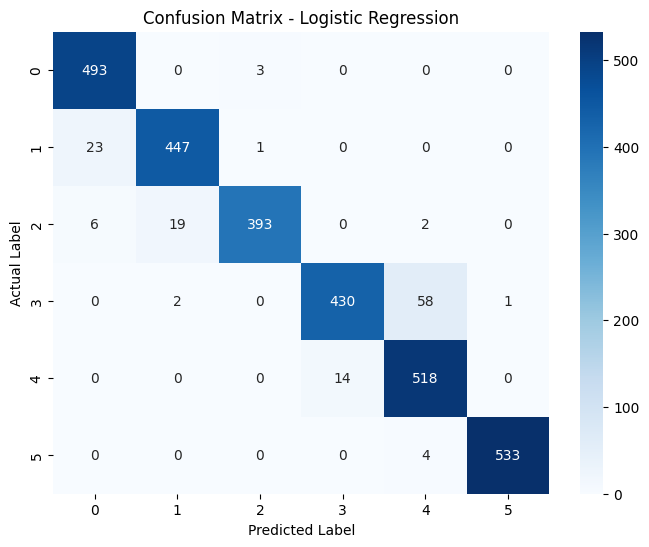

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

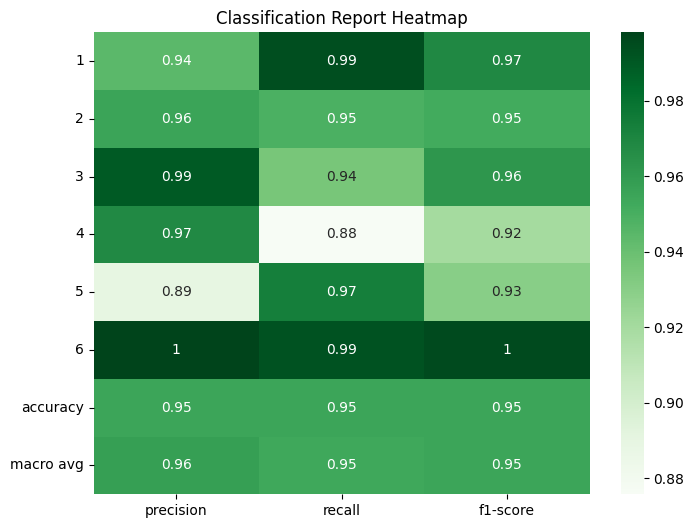

In [38]:
from sklearn.metrics import classification_report
import pandas as pd

# Generate classification report
report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="Greens")

plt.title("Classification Report Heatmap")
plt.show()

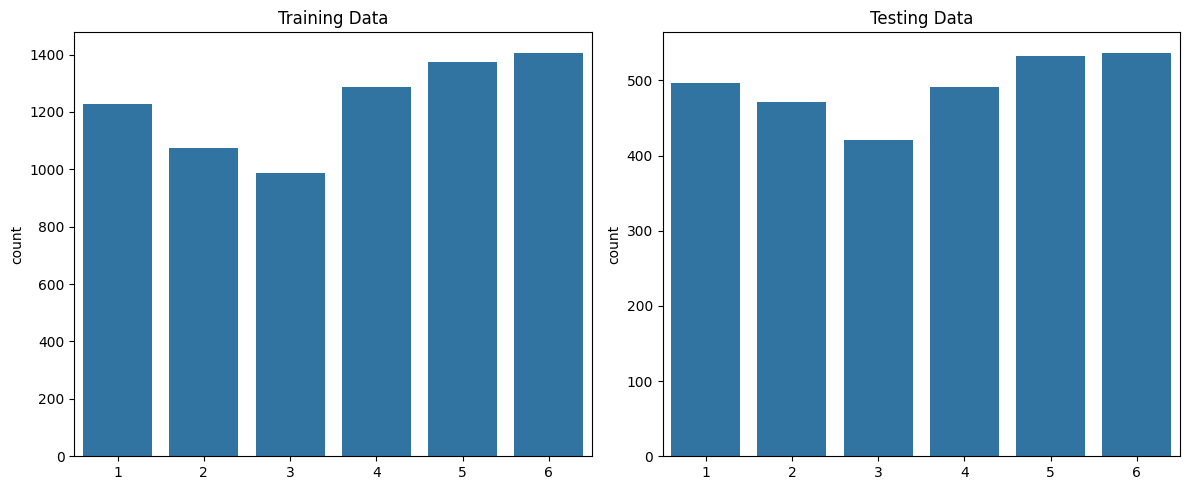

In [39]:
plt.figure(figsize=(12,5))

# Training
plt.subplot(1,2,1)
sns.countplot(x=y_train.values.ravel())
plt.title("Training Data")

# Testing
plt.subplot(1,2,2)
sns.countplot(x=y_test.values.ravel())
plt.title("Testing Data")

plt.tight_layout()
plt.show()